In [1]:
import pandas as pd



In [94]:
plasma_data = pd.read_excel('PR80_30/plasma_data_imputed_30.xlsx')
tissue_data = pd.read_excel('PR80_30/tissue_data_imputed_30.xlsx')
gene_edges_model_union = pd.read_csv('PR80_30/gene_edges_model_union_400.csv')
gene_edges_model_common = pd.read_csv('PR80_30/gene_edges_model_common_400.csv')
gene_edges_model_plasma = pd.read_csv('PR80_30/gene_edges_model_plasma_400.csv')
gene_edges_model_tissue = pd.read_csv('PR80_30/gene_edges_model_tissue_400.csv')
print(plasma_data.shape)
print(tissue_data.shape)

(1531, 53)
(6630, 53)


In [174]:
tissue_data.head()

,Genes,Sample 60,Sample 65,Sample 18,Sample 59,Sample 42,Sample 30,Sample 31,Sample 77,Sample 32,...,Sample 1,Sample 36,Sample 29,Sample 5,Sample 86,Sample 52,Sample 12,Sample 20,Sample 51,Sample 48
0,ABRACL,2.896485,2.733448,2.790386,2.790386,2.819256,2.790386,2.785565,2.647872,2.679108,...,2.790386,2.785720,2.943164,2.790386,2.821655,2.809657,2.790386,2.790386,2.779709,2.790386
1,ADAMTS4,2.884181,2.866258,2.852441,2.655039,2.866258,2.866258,2.674965,2.866258,2.771397,...,2.866258,2.966654,3.014473,2.866258,2.866258,2.768315,2.639068,2.866258,2.880074,2.866258
2,ADCK5,2.891597,2.887296,2.873377,2.873377,2.895024,2.873377,3.025889,2.937286,2.873377,...,2.873377,2.871189,2.858788,2.873377,2.873377,2.968413,2.909434,2.813288,2.796874,2.868227
3,ADCY7,2.877753,2.917373,2.762620,2.877753,2.871214,2.877753,2.975849,2.811832,2.877753,...,2.791398,2.875939,2.918381,2.877753,2.852834,2.925028,2.903680,2.914426,3.023003,2.877753
4,AFTPH,2.781674,2.852603,2.852603,2.811372,2.923016,2.852603,2.931570,2.947874,2.852603,...,2.852603,2.852603,2.852603,2.852603,2.874577,2.816562,2.925535,2.870496,2.997733,2.852603


Plasma shape: (1531, 53)
Tissue shape: (6630, 53)

--- Missingness ---
Plasma missing: 0
Tissue missing: 0
Plasma missing %: 0.0
Tissue missing %: 0.0

Numeric dimensions:
Plasma: (1531, 52)
Tissue: (6630, 52)
Plasma proteins: 1531
Tissue proteins: 6630
Common proteins: 1402
Plasma protein variance:
count    1531.000000
mean        0.020910
std         0.016177
min         0.001192
25%         0.008196
50%         0.015613
75%         0.030095
max         0.089813
dtype: float64

Tissue protein variance:
count    6630.000000
mean        0.012811
std         0.010278
min         0.000916
25%         0.006248
50%         0.010204
75%         0.016220
max         0.125923
dtype: float64
Plasma zero variance: 0
Tissue zero variance: 0
Plasma near-zero variance: 0
Tissue near-zero variance: 0


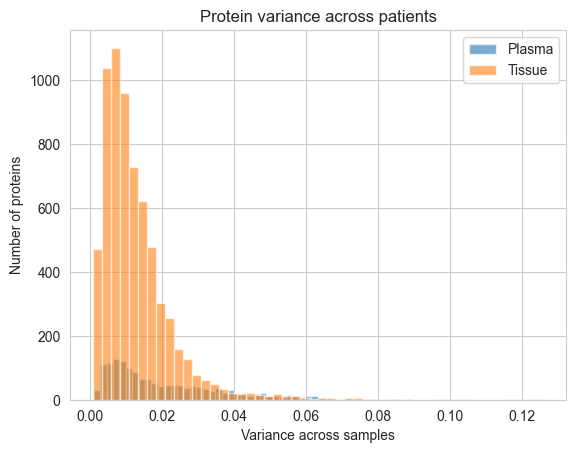


--- Sample variance ---
Plasma:
count    1531.000000
mean        0.020910
std         0.016177
min         0.001192
25%         0.008196
50%         0.015613
75%         0.030095
max         0.089813
dtype: float64

Tissue:
count    6630.000000
mean        0.012811
std         0.010278
min         0.000916
25%         0.006248
50%         0.010204
75%         0.016220
max         0.125923
dtype: float64


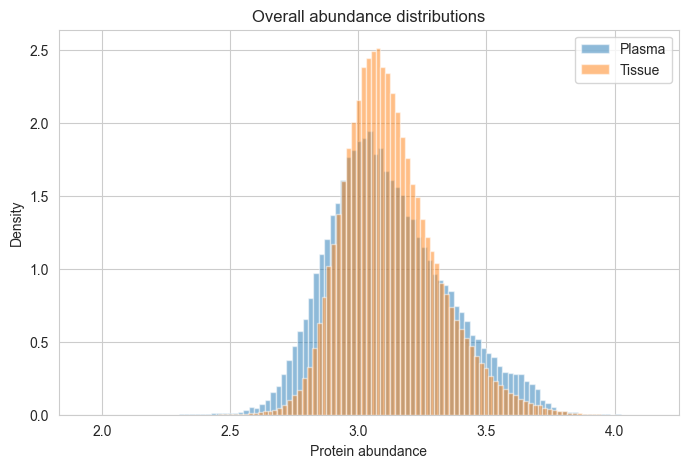

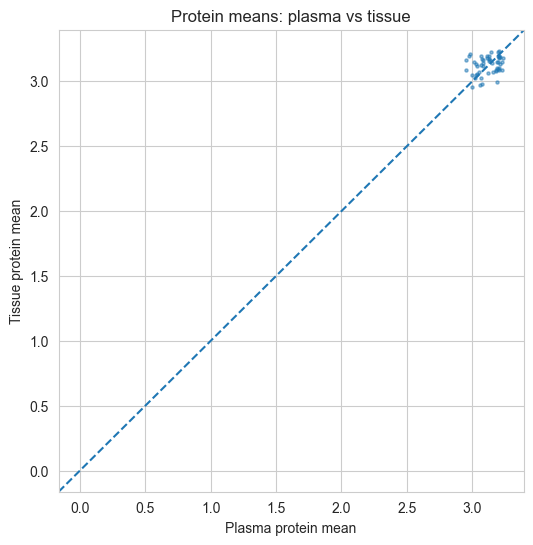

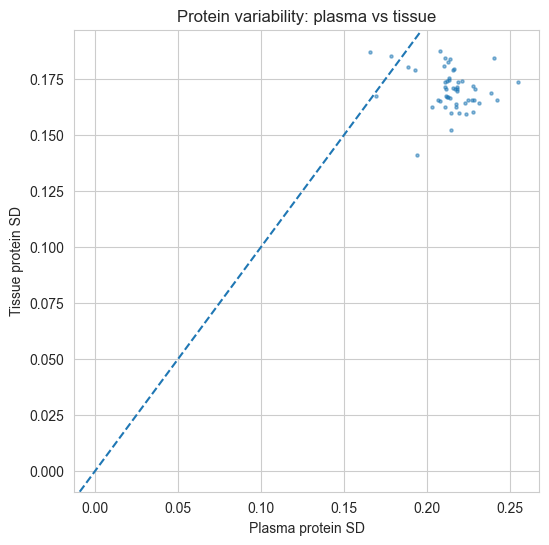


--- Within-modality sample correlations ---
Plasma mean sample correlation: 0.2654354255961849
Tissue mean sample correlation: 0.418622936423637
Plasma max off-diagonal correlation: 0.9937426194961057
Tissue max off-diagonal correlation: 0.9988364526675103

Common proteins: 52
Mean cross-modality sample correlation: 0.0844997879330737
Max cross-modality sample correlation: 0.7496989197132272
Min cross-modality sample correlation: -0.6685541421309765


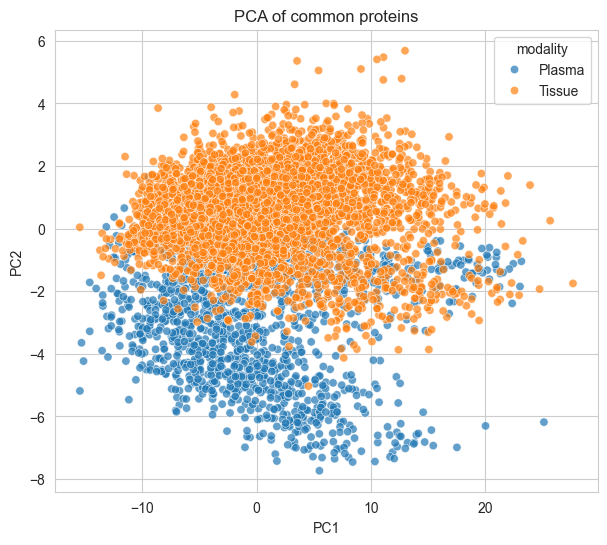


PCA explained variance: [0.70141136 0.06815433]

--- Modality separation ---
PC1 AUC: 0.47110968589817476
PC2 AUC: 0.05343730819967036


In [175]:
##### quick sanity check

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr


print("Plasma shape:", plasma_data.shape)
print("Tissue shape:", tissue_data.shape)


# ============================================================
# 1. Missing values
# ============================================================

print("\n--- Missingness ---")

print(
    "Plasma missing:",
    plasma_data.isna().sum().sum()
)

print(
    "Tissue missing:",
    tissue_data.isna().sum().sum()
)

print(
    "Plasma missing %:",
    plasma_data.isna().mean().mean() * 100
)

print(
    "Tissue missing %:",
    tissue_data.isna().mean().mean() * 100
)


# ============================================================
# 2. Numeric columns
# ============================================================

plasma_numeric = plasma_data.select_dtypes(
    include=np.number
)

tissue_numeric = tissue_data.select_dtypes(
    include=np.number
)

print("\nNumeric dimensions:")
print("Plasma:", plasma_numeric.shape)
print("Tissue:", tissue_numeric.shape)


# ============================================================
# 3. Per-protein variance
# ============================================================
plasma_proteins = plasma_data["Genes"]
tissue_proteins = tissue_data["Genes"]

common_proteins = (
    set(plasma_proteins)
    &
    set(tissue_proteins)
)

print("Plasma proteins:", len(plasma_proteins))
print("Tissue proteins:", len(tissue_proteins))
print("Common proteins:", len(common_proteins))

plasma_numeric = plasma_data.drop(columns=["Genes"])
tissue_numeric = tissue_data.drop(columns=["Genes"])

plasma_protein_var = plasma_numeric.var(axis=1)
tissue_protein_var = tissue_numeric.var(axis=1)

print("Plasma protein variance:")
print(plasma_protein_var.describe())

print("\nTissue protein variance:")
print(tissue_protein_var.describe())

print(
    "Plasma zero variance:",
    (plasma_protein_var == 0).sum()
)

print(
    "Tissue zero variance:",
    (tissue_protein_var == 0).sum()
)

print(
    "Plasma near-zero variance:",
    (plasma_protein_var < 1e-4).sum()
)

print(
    "Tissue near-zero variance:",
    (tissue_protein_var < 1e-4).sum()
)

plt.hist(
    plasma_protein_var,
    bins=50,
    alpha=0.6,
    label="Plasma"
)

plt.hist(
    tissue_protein_var,
    bins=50,
    alpha=0.6,
    label="Tissue"
)

plt.xlabel("Variance across samples")
plt.ylabel("Number of proteins")
plt.legend()
plt.title("Protein variance across patients")
plt.show()
# ============================================================
# 4. Sample-level variance
# ============================================================

plasma_sample_var = plasma_numeric.var(axis=1)
tissue_sample_var = tissue_numeric.var(axis=1)

print("\n--- Sample variance ---")

print("Plasma:")
print(plasma_sample_var.describe())

print("\nTissue:")
print(tissue_sample_var.describe())


# ============================================================
# 5. Distribution of all protein values
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    plasma_numeric.values.flatten(),
    bins=100,
    alpha=0.5,
    density=True,
    label="Plasma"
)

plt.hist(
    tissue_numeric.values.flatten(),
    bins=100,
    alpha=0.5,
    density=True,
    label="Tissue"
)

plt.xlabel("Protein abundance")
plt.ylabel("Density")
plt.legend()
plt.title("Overall abundance distributions")
plt.show()


# ============================================================
# 6. Mean and SD per protein
# ============================================================

plasma_means = plasma_numeric.mean(axis=0)
tissue_means = tissue_numeric.mean(axis=0)

plasma_stds = plasma_numeric.std(axis=0)
tissue_stds = tissue_numeric.std(axis=0)

plt.figure(figsize=(6, 6))

plt.scatter(
    plasma_means,
    tissue_means,
    s=5,
    alpha=0.5
)

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.xlabel("Plasma protein mean")
plt.ylabel("Tissue protein mean")
plt.title("Protein means: plasma vs tissue")
plt.show()


# ============================================================
# 7. Protein SD comparison
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    plasma_stds,
    tissue_stds,
    s=5,
    alpha=0.5
)

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.xlabel("Plasma protein SD")
plt.ylabel("Tissue protein SD")
plt.title("Protein variability: plasma vs tissue")
plt.show()


# ============================================================
# 8. Sample-to-sample correlations within each modality
# ============================================================

plasma_sample_corr = plasma_numeric.T.corr()
tissue_sample_corr = tissue_numeric.T.corr()

# Remove diagonal
plasma_offdiag = plasma_sample_corr.values[
    ~np.eye(len(plasma_sample_corr), dtype=bool)
]

tissue_offdiag = tissue_sample_corr.values[
    ~np.eye(len(tissue_sample_corr), dtype=bool)
]

print("\n--- Within-modality sample correlations ---")

print(
    "Plasma mean sample correlation:",
    plasma_offdiag.mean()
)

print(
    "Tissue mean sample correlation:",
    tissue_offdiag.mean()
)

print(
    "Plasma max off-diagonal correlation:",
    plasma_offdiag.max()
)

print(
    "Tissue max off-diagonal correlation:",
    tissue_offdiag.max()
)


# ============================================================
# 9. Cross-modality correlations
# ============================================================

# Only common proteins
common_proteins = (
    plasma_numeric.columns
    .intersection(tissue_numeric.columns)
)

print(
    "\nCommon proteins:",
    len(common_proteins)
)

plasma_common = plasma_numeric[common_proteins]
tissue_common = tissue_numeric[common_proteins]

cross_corr = np.corrcoef(
    plasma_common.values,
    tissue_common.values
)

n_plasma = len(plasma_common)

cross_corr = cross_corr[
    :n_plasma,
    n_plasma:
]

print(
    "Mean cross-modality sample correlation:",
    cross_corr.mean()
)

print(
    "Max cross-modality sample correlation:",
    cross_corr.max()
)

print(
    "Min cross-modality sample correlation:",
    cross_corr.min()
)


# ============================================================
# 10. PCA: can tissue and plasma be distinguished?
# ============================================================

combined = pd.concat(
    [
        plasma_common,
        tissue_common
    ],
    axis=0,
    ignore_index=True
)

labels = np.array(
    ["Plasma"] * len(plasma_common)
    +
    ["Tissue"] * len(tissue_common)
)

X = StandardScaler().fit_transform(combined)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "modality": labels
})

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="modality",
    alpha=0.7
)

plt.title("PCA of common proteins")
plt.show()

print(
    "\nPCA explained variance:",
    pca.explained_variance_ratio_
)


# ============================================================
# 11. Can PC1 distinguish tissue and plasma?
# ============================================================

y = (labels == "Plasma").astype(int)

auc_pc1 = roc_auc_score(
    y,
    X_pca[:, 0]
)

auc_pc2 = roc_auc_score(
    y,
    X_pca[:, 1]
)

print("\n--- Modality separation ---")
print("PC1 AUC:", auc_pc1)
print("PC2 AUC:", auc_pc2)


In [104]:
print(tissue_data.isnull().sum())
graph_genes = set(
    gene_edges_model_union["gene1"]
).union(
    set(gene_edges_model_union["gene2"])
)

graph_genes_tissue = set(
    gene_edges_model_tissue["gene1"]
).union(
    set(gene_edges_model_tissue["gene2"])
)

graph_genes_plasma = set(
    gene_edges_model_plasma["gene1"]
).union(
    set(gene_edges_model_plasma["gene2"])
)

graph_genes_common = set(
    gene_edges_model_common["gene1"]
).union(
    set(gene_edges_model_common["gene2"])
)



plasma_proteins = set(protein for protein in plasma_data['Genes'].values if protein in graph_genes)
tissue_proteins = set(protein for protein in tissue_data['Genes'].values if protein in graph_genes)


shared_proteins = set(protein for protein in tissue_proteins if protein in plasma_proteins)
plasma_only_proteins = plasma_proteins.difference(shared_proteins)
tissue_only_proteins = tissue_proteins.difference(shared_proteins)


print(f'Shared proteins: {len(shared_proteins)}')
print(f'Plasma only proteins: {len(plasma_only_proteins)}')
print(f'Tissue only proteins: {len(tissue_only_proteins)}')

Genes        0
Sample 60    0
Sample 65    0
Sample 18    0
Sample 59    0
Sample 42    0
Sample 30    0
Sample 31    0
Sample 77    0
Sample 32    0
Sample 7     0
Sample 55    0
Sample 76    0
Sample 28    0
Sample 72    0
Sample 88    0
Sample 11    0
Sample 64    0
Sample 25    0
Sample 78    0
Sample 83    0
Sample 70    0
Sample 90    0
Sample 45    0
Sample 85    0
Sample 17    0
Sample 22    0
Sample 57    0
Sample 66    0
Sample 38    0
Sample 82    0
Sample 39    0
Sample 61    0
Sample 16    0
Sample 23    0
Sample 24    0
Sample 87    0
Sample 73    0
Sample 15    0
Sample 49    0
Sample 75    0
Sample 79    0
Sample 34    0
Sample 1     0
Sample 36    0
Sample 29    0
Sample 5     0
Sample 86    0
Sample 52    0
Sample 12    0
Sample 20    0
Sample 51    0
Sample 48    0
dtype: int64
Shared proteins: 1266
Plasma only proteins: 92
Tissue only proteins: 5132


In [105]:
tissue_data.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='str')

In [106]:
tissue_data = tissue_data.drop(columns=['Unnamed: 0'])

KeyError: "['Unnamed: 0'] not found in axis"

In [107]:
print(tissue_data.columns)

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='str')


In [108]:
print(tissue_data.dtypes)
print(plasma_data.dtypes)

Genes            str
Sample 60    float64
Sample 65    float64
Sample 18    float64
Sample 59    float64
Sample 42    float64
Sample 30    float64
Sample 31    float64
Sample 77    float64
Sample 32    float64
Sample 7     float64
Sample 55    float64
Sample 76    float64
Sample 28    float64
Sample 72    float64
Sample 88    float64
Sample 11    float64
Sample 64    float64
Sample 25    float64
Sample 78    float64
Sample 83    float64
Sample 70    float64
Sample 90    float64
Sample 45    float64
Sample 85    float64
Sample 17    float64
Sample 22    float64
Sample 57    float64
Sample 66    float64
Sample 38    float64
Sample 82    float64
Sample 39    float64
Sample 61    float64
Sample 16    float64
Sample 23    float64
Sample 24    float64
Sample 87    float64
Sample 73    float64
Sample 15    float64
Sample 49    float64
Sample 75    float64
Sample 79    float64
Sample 34    float64
Sample 1     float64
Sample 36    float64
Sample 29    float64
Sample 5     float64
Sample 86    

In [110]:
tissue_tmp = tissue_data.set_index("Genes")
print(tissue_tmp.dtypes.value_counts())

float64    52
Name: count, dtype: int64


In [115]:
tissue_tmp = tissue_data.set_index("Genes")

tissue_z = (
    tissue_tmp
    .sub(tissue_tmp.mean(axis=1), axis=0)
    .div(tissue_tmp.std(axis=1), axis=0)
)

plasma_tmp = plasma_data.set_index("Genes")
plasma_z = (
    plasma_tmp
    .sub(plasma_tmp.mean(axis=1), axis=0)
    .div(plasma_tmp.std(axis=1), axis=0)
)


In [116]:
print(tissue_data.isnull().sum())

Genes        0
Sample 60    0
Sample 65    0
Sample 18    0
Sample 59    0
Sample 42    0
Sample 30    0
Sample 31    0
Sample 77    0
Sample 32    0
Sample 7     0
Sample 55    0
Sample 76    0
Sample 28    0
Sample 72    0
Sample 88    0
Sample 11    0
Sample 64    0
Sample 25    0
Sample 78    0
Sample 83    0
Sample 70    0
Sample 90    0
Sample 45    0
Sample 85    0
Sample 17    0
Sample 22    0
Sample 57    0
Sample 66    0
Sample 38    0
Sample 82    0
Sample 39    0
Sample 61    0
Sample 16    0
Sample 23    0
Sample 24    0
Sample 87    0
Sample 73    0
Sample 15    0
Sample 49    0
Sample 75    0
Sample 79    0
Sample 34    0
Sample 1     0
Sample 36    0
Sample 29    0
Sample 5     0
Sample 86    0
Sample 52    0
Sample 12    0
Sample 20    0
Sample 51    0
Sample 48    0
dtype: int64


In [163]:
gene_to_idx = {
    gene: i
    for i, gene in enumerate(graph_genes_common)
}

In [164]:
import torch
###Create edge index
edge_index = torch.tensor(
    [
        [
            gene_to_idx[g1],
            gene_to_idx[g2]
        ]
        for g1, g2 in zip(
            gene_edges_model_common["gene1"],
            gene_edges_model_common["gene2"]
        )
    ],
    dtype=torch.long
).t().contiguous()

In [165]:
#bidirectional
edge_index = torch.cat(
    [
        edge_index,
        edge_index.flip(0)
    ],
    dim=1
)
print(edge_index.shape)

torch.Size([2, 53616])


In [166]:
#edge confidence attribute
edge_attr = torch.tensor(
    gene_edges_model_common["combined_score"].values / 1000,
    dtype=torch.float
)
edge_attr = torch.cat(
    [
        edge_attr,
        edge_attr
    ]
)
print(edge_attr.shape)

torch.Size([53616])


In [24]:
df_tissue_dupl = tissue_data.copy()
tissue_data = tissue_data.set_index('Genes')
duplicates = set(tissue_data.index[tissue_data.index.duplicated(keep=False)])
print(duplicates)


df_tissue_dupl['missing'] = df_tissue_dupl.iloc[:, 1:].isnull().mean(axis=1)
df_tissue_dupl['mean_intensity'] = df_tissue_dupl.iloc[:, 2:].mean(axis=1)
df_tissue_dupl = df_tissue_dupl.sort_values(['Genes','mean_intensity','missing'],ascending=True)
df_tissue_dupl_subset = df_tissue_dupl.loc[df_tissue_dupl.index.isin(duplicates)]
print(df_tissue_dupl_subset[['Genes','missing','mean_intensity']].head(10))
df_tissue_dupl = df_tissue_dupl.drop_duplicates(subset='Genes', keep='last')
assert df_tissue_dupl['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

df_tissue_dupl = df_tissue_dupl.drop(columns=['missing', 'mean_intensity'])
tissue_data = df_tissue_dupl
assert tissue_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"


set()
Empty DataFrame
Columns: [Genes, missing, mean_intensity]
Index: []


In [121]:
dublicates= plasma_data.loc[plasma_data['Genes'].duplicated(keep=False),'Genes'].unique()
print(dublicates)
print(len(dublicates))

<StringArray>
[]
Length: 0, dtype: str
0


In [26]:
tissue_data.to_csv('tissue_data_imputed_30_renamed.csv') #three extra duplicates removed

In [122]:
tissue_expression = (
    tissue_data
    .set_index("Genes")
)

In [45]:
tissue_expression.columns

Index(['Sample 60', 'Sample 65', 'Sample 18', 'Sample 59', 'Sample 42',
       'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32', 'Sample 7',
       'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72', 'Sample 88',
       'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78', 'Sample 83',
       'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85', 'Sample 17',
       'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38', 'Sample 82',
       'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23', 'Sample 24',
       'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49', 'Sample 75',
       'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36', 'Sample 29',
       'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12', 'Sample 20',
       'Sample 51', 'Sample 48'],
      dtype='str')

In [123]:

tissue_z = (
    tissue_expression
    .sub(tissue_expression.mean(axis=1), axis=0)
    .div(tissue_expression.std(axis=1), axis=0)
)


In [141]:
def create_graph_sample(
    expression,
    gene_to_idx
):

    num_nodes = len(gene_to_idx)


    x = torch.zeros(
    (num_nodes, 1),# change for number of features
    dtype=torch.float
    )

    for gene, idx in gene_to_idx.items():

        if gene in expression.index:
            x[idx, 0] = expression.loc[gene]
            
          #  x[idx, 1] = 1
            
        else:
            x[idx, 0] = 0
           # x[idx, 1] = 0
            
        
            
            
        

    return x

In [125]:
print(tissue_expression.columns)

Index(['Sample 60', 'Sample 65', 'Sample 18', 'Sample 59', 'Sample 42',
       'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32', 'Sample 7',
       'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72', 'Sample 88',
       'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78', 'Sample 83',
       'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85', 'Sample 17',
       'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38', 'Sample 82',
       'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23', 'Sample 24',
       'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49', 'Sample 75',
       'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36', 'Sample 29',
       'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12', 'Sample 20',
       'Sample 51', 'Sample 48'],
      dtype='str')


In [126]:
print(tissue_expression.columns)

Index(['Sample 60', 'Sample 65', 'Sample 18', 'Sample 59', 'Sample 42',
       'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32', 'Sample 7',
       'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72', 'Sample 88',
       'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78', 'Sample 83',
       'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85', 'Sample 17',
       'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38', 'Sample 82',
       'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23', 'Sample 24',
       'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49', 'Sample 75',
       'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36', 'Sample 29',
       'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12', 'Sample 20',
       'Sample 51', 'Sample 48'],
      dtype='str')


In [167]:
from torch_geometric.data import Data


graphs = []

for sample in tissue_z.columns:
    expression = tissue_z[sample]
    print(expression)
    x = create_graph_sample(
        expression,
        gene_to_idx=gene_to_idx
    )

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        modality = 1,
        patient_id = sample
    )

    graphs.append(data)
print(graphs[0])

Genes
ABRACL     1.567256
ADAMTS4    0.399477
ADCK5      0.286323
ADCY7      0.025225
AFTPH     -1.273893
             ...   
MRPL57    -0.144178
PRR14      0.722994
RCOR3      0.557349
TRIR       0.340514
UNC119B    0.353080
Name: Sample 60, Length: 6630, dtype: float64
Genes
ABRACL    -0.623494
ADAMTS4    0.203014
ADCK5      0.218930
ADCY7      0.768833
AFTPH      0.024709
             ...   
MRPL57     0.994579
PRR14      0.596730
RCOR3      1.792478
TRIR       0.326560
UNC119B    0.147276
Name: Sample 65, Length: 6630, dtype: float64
Genes
ABRACL     0.141589
ADAMTS4    0.051565
ADCK5      0.000797
ADCY7     -2.135642
AFTPH      0.024709
             ...   
MRPL57    -1.118156
PRR14      1.018320
RCOR3     -0.677009
TRIR      -2.179360
UNC119B   -0.654299
Name: Sample 18, Length: 6630, dtype: float64
Genes
ABRACL     0.141589
ADAMTS4   -2.112214
ADCK5      0.000797
ADCY7      0.025225
AFTPH     -0.730171
             ...   
MRPL57    -0.319517
PRR14      0.181342
RCOR3     -0.50807

In [ ]:
#plasma: Data(x=[1340, 1], edge_index=[2, 56820], edge_attr=[56820], modality=1, patient_id='Sample 60')
#tissue : Data(x=[6397, 1], edge_index=[2, 560456], edge_attr=[560456], modality=1, patient_id='Sample 60')


In [147]:
print(len(graphs))

52


In [148]:
plasma_expression = plasma_data.set_index("Genes")
plasma_z = (
    plasma_expression
    .sub(plasma_expression.mean(axis=1), axis=0)
    .div(plasma_expression.std(axis=1), axis=0)
)

In [168]:

for sample in plasma_z.columns:
    expression_1 = plasma_z[sample]

    x_plasma = create_graph_sample(
    expression_1,
    gene_to_idx=gene_to_idx
    )


    data = Data(
        x=x_plasma,
        edge_index=edge_index,
        edge_attr=edge_attr,
        modality = 0,
        patient_id = sample
   
    )

    graphs.append(data)
print(graphs[0])


Data(x=[1253, 1], edge_index=[2, 53616], edge_attr=[53616], modality=1, patient_id='Sample 60')


In [52]:
#means:

# 6559 nodes
# 2 node features per node
# 3,581,542 directed edges
# 1 edge weight per edge

In [150]:
print(len(graphs))

104


In [132]:
print(graphs[0].x[50:])

tensor([[-0.8476,  1.0000],
        [-0.0154,  1.0000],
        [-1.3000,  1.0000],
        ...,
        [ 0.0392,  1.0000],
        [-0.4217,  1.0000],
        [-0.1298,  1.0000]])


In [133]:
idx_to_gene = {v: k for k, v in gene_to_idx.items()}

In [134]:
# show proteins that are marked as missing
graph = graphs[103]
idx_to_gene = {v:k for k,v in gene_to_idx.items()}

missing_nodes = torch.where(graph.x[:,1] == 0)[0]

print("Number missing:", len(missing_nodes))

for idx in missing_nodes[:20]:
    gene = idx_to_gene[idx.item()]
    print(
        gene,
        "abundance:", graph.x[idx,0].item(),
        "is_measured:", graph.x[idx,1].item()
    )

Number missing: 5132
NHP2 abundance: 0.0 is_measured: 0.0
IDH3B abundance: 0.0 is_measured: 0.0
MRPL14 abundance: 0.0 is_measured: 0.0
ARHGAP35 abundance: 0.0 is_measured: 0.0
MAPK3 abundance: 0.0 is_measured: 0.0
NMRAL1 abundance: 0.0 is_measured: 0.0
UBE2F abundance: 0.0 is_measured: 0.0
MRPL19 abundance: 0.0 is_measured: 0.0
PLD2 abundance: 0.0 is_measured: 0.0
OGT abundance: 0.0 is_measured: 0.0
TSFM abundance: 0.0 is_measured: 0.0
EMC7 abundance: 0.0 is_measured: 0.0
PREP abundance: 0.0 is_measured: 0.0
GANC abundance: 0.0 is_measured: 0.0
HMGN5 abundance: 0.0 is_measured: 0.0
CD99L2 abundance: 0.0 is_measured: 0.0
RPL18 abundance: 0.0 is_measured: 0.0
MTHFD1 abundance: 0.0 is_measured: 0.0
CASKIN2 abundance: 0.0 is_measured: 0.0
TGM5 abundance: 0.0 is_measured: 0.0


In [135]:
for i in range(10):
    print(idx_to_gene[i], graphs[0].x[i])

NHP2 tensor([-0.3981,  1.0000])
IDH3B tensor([0.6688, 1.0000])
MRPL14 tensor([0.1691, 1.0000])
ARHGAP35 tensor([-0.2837,  1.0000])
SPTAN1 tensor([0.3390, 1.0000])
MAPK3 tensor([-0.1695,  1.0000])
NMRAL1 tensor([-0.9498,  1.0000])
UBE2F tensor([0.1609, 1.0000])
MRPL19 tensor([-0.0460,  1.0000])
PLD2 tensor([-0.8144,  1.0000])


In [85]:
idx = gene_to_idx["A2M"]

print(idx)
print(graphs[0].x[idx])

556
tensor([0.0543, 1.0000])


In [136]:
idx_to_gene = {v:k for k,v in gene_to_idx.items()}

missing_nodes = torch.where(graph.x[:,1] == 0)[0]

print("Number missing:", len(missing_nodes))

for idx in missing_nodes[20:]:
    gene = idx_to_gene[idx.item()]
    print(
        gene,
        "abundance:", graph.x[idx,0].item(),
        "is_measured:", graph.x[idx,1].item()
    )

Number missing: 5132
CDKN2A abundance: 0.0 is_measured: 0.0
GLA abundance: 0.0 is_measured: 0.0
PSPC1 abundance: 0.0 is_measured: 0.0
DMD abundance: 0.0 is_measured: 0.0
CNOT1 abundance: 0.0 is_measured: 0.0
CDC73 abundance: 0.0 is_measured: 0.0
ABAT abundance: 0.0 is_measured: 0.0
UHRF2 abundance: 0.0 is_measured: 0.0
RTCB abundance: 0.0 is_measured: 0.0
ALDH1L2 abundance: 0.0 is_measured: 0.0
STRN3 abundance: 0.0 is_measured: 0.0
DDX39B abundance: 0.0 is_measured: 0.0
RALY abundance: 0.0 is_measured: 0.0
VPS39 abundance: 0.0 is_measured: 0.0
FIG4 abundance: 0.0 is_measured: 0.0
CA4 abundance: 0.0 is_measured: 0.0
S100A11 abundance: 0.0 is_measured: 0.0
TPRKB abundance: 0.0 is_measured: 0.0
DAGLB abundance: 0.0 is_measured: 0.0
JMJD7 abundance: 0.0 is_measured: 0.0
SLC16A3 abundance: 0.0 is_measured: 0.0
TM7SF2 abundance: 0.0 is_measured: 0.0
CDC37L1 abundance: 0.0 is_measured: 0.0
SLC35A3 abundance: 0.0 is_measured: 0.0
PSMD12 abundance: 0.0 is_measured: 0.0
EPS8L2 abundance: 0.0 is_

In [137]:
print(
    tissue_data.loc[
        tissue_data["Genes"] == "A2M",
        "Sample 60"
    ]
)

105    3.574198
Name: Sample 60, dtype: float64


In [88]:
print(graphs[0].x.shape)
print(torch.unique(graphs[0].x[:,1], return_counts=True))

torch.Size([6549, 2])
(tensor([0., 1.]), tensor([  97, 6452]))


In [66]:
print(gene_to_idx)

{'AARS2': 0, 'A2M': 1, 'ERLEC1': 2, 'EXD2': 3, 'RNF181': 4, 'ZNF207': 5, 'FAM114A2': 6, 'HNRNPU': 7, 'TSPAN14': 8, 'YIPF4': 9, 'WDFY4': 10, 'TMEM106B': 11, 'PLA2G4C': 12, 'ELOVL1': 13, 'KIDINS220': 14, 'FHL3': 15, 'FARS2': 16, 'CCNK': 17, 'BCKDHB': 18, 'C9': 19, 'RNF13': 20, 'RPS26': 21, 'C12orf4': 22, 'HDAC1': 23, 'HBB': 24, 'COPZ1': 25, 'ARHGDIB': 26, 'SELENOF': 27, 'AHSP': 28, 'BAG2': 29, 'ALDH9A1': 30, 'RNF135': 31, 'GPX3': 32, 'SDHA': 33, 'CALHM2': 34, 'PUDP': 35, 'NFIX': 36, 'NMNAT3': 37, 'VCAM1': 38, 'ARID1A': 39, 'NUP107': 40, 'NCK1': 41, 'LUC7L2': 42, 'MANBAL': 43, 'HPGDS': 44, 'SRRT': 45, 'HDDC3': 46, 'IL1RN': 47, 'RBPJ': 48, 'EHD1': 49, 'BCAS3': 50, 'ACTN1': 51, 'EXOC6': 52, 'FUS': 53, 'HBQ1': 54, 'GPAM': 55, 'PSPH': 56, 'TMED5': 57, 'BUB3': 58, 'RBM4': 59, 'TM9SF2': 60, 'NUP43': 61, 'NME3': 62, 'GPCPD1': 63, 'UBA2': 64, 'C6orf120': 65, 'USO1': 66, 'GOLT1B': 67, 'MAP1LC3B': 68, 'KRT6B': 69, 'GLIPR1': 70, 'NCBP3': 71, 'GBP1': 72, 'RTCB': 73, 'INPP5D': 74, 'RALGAPA2': 75, 'CUL

In [169]:
gene_to_idx_df = (
    pd.DataFrame.from_dict(gene_to_idx, orient="index", columns=['idx'])
    .rename_axis("Gene")
    .reset_index()
)
print(gene_to_idx_df.head())

     Gene  idx
0    ARF4    0
1   COX5B    1
2    GYG1    2
3   AP2S1    3
4  SPTAN1    4


In [170]:
gene_to_idx_df.to_csv('PR80_30/gene_to_idx_400_common_only.csv')

In [171]:
import torch

torch.save(graphs, "PR80_30/proteins_graphs_400_common_only.pt")